In [2]:
import pandas as pd

url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
!wget -q {url} -O bank_marketing.zip
!unzip -o -q bank_marketing.zip
!unzip -o -q bank-additional.zip

# Check if the file exists before trying to read it
!ls bank-additional/

df = pd.read_csv("bank-additional/bank-additional-full.csv", sep=';')
df.head()

bank-additional.csv  bank-additional-full.csv  bank-additional-names.txt


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.shape

(41188, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
df['y'].value_counts()

,count
y,
no,36548
yes,4640


In [8]:
df.isnull().sum()


,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [9]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

job ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital ['married' 'single' 'divorced' 'unknown']
education ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default ['no' 'unknown' 'yes']
housing ['no' 'yes' 'unknown']
loan ['no' 'yes' 'unknown']
contact ['telephone' 'cellular']
month ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week ['mon' 'tue' 'wed' 'thu' 'fri']
poutcome ['nonexistent' 'failure' 'success']
y ['no' 'yes']


In [10]:
for col in ['job', 'marital', 'education', 'default', 'housing', 'loan']:
    print(col, (df[col] == 'unknown').sum())

job 330
marital 80
education 1731
default 8597
housing 990
loan 990


In [11]:
df[['age', 'campaign', 'pdays', 'previous']].describe()

,age,campaign,pdays,previous
count,41188.00000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963
std,10.42125,2.770014,186.910907,0.494901
min,17.00000,1.000000,0.000000,0.000000
25%,32.00000,1.000000,999.000000,0.000000
50%,38.00000,2.000000,999.000000,0.000000
75%,47.00000,3.000000,999.000000,0.000000
max,98.00000,56.000000,999.000000,7.000000


In [12]:
(df['pdays'] == 999).sum()

np.int64(39673)

In [15]:
df_clean = df.drop(columns=['duration', 'default'])
df_clean['was_previously_contacted'] = df_clean['pdays'] != 999

In [16]:
df_clean.shape

(41188, 20)

In [17]:
df_clean.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_previously_contacted
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
1,57,services,married,high.school,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
2,37,services,married,high.school,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
4,56,services,married,high.school,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False


In [ ]:
df_clean.dtypes

import pandas as pd
import os

# Create 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

df_clean.to_csv("data/dataset.csv", index=False)
print("df_clean saved to data/dataset.csv")

In [19]:
from sklearn.model_selection import train_test_split

df_model = pd.get_dummies(df_clean, columns=['job','marital','education','housing','loan','contact','month','day_of_week','poutcome'], drop_first=True)
df_model['y'] = df_model['y'].map({'no': 0, 'yes': 1})

X = df_model.drop(columns=['y'])
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(32950, 51) (8238, 51)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9003398883224083
Precision: 0.6903914590747331
Recall: 0.20905172413793102
F1: 0.32092638544251445
Confusion Matrix:
 [[7223   87]
 [ 734  194]]


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train_scaled, y_train)
y_pred2 = model2.predict(X_test_scaled)

print("Recall:", recall_score(y_test, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))

Recall: 0.2209051724137931
Confusion Matrix:
 [[7219   91]
 [ 723  205]]


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8965768390386016
Precision: 0.5811965811965812
Recall: 0.29310344827586204
F1: 0.38968481375358166
Confusion Matrix:
 [[7114  196]
 [ 656  272]]


In [23]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(10))

age                0.161590
euribor3m          0.143195
campaign           0.085616
nr.employed        0.055469
emp.var.rate       0.051502
housing_yes        0.034431
cons.conf.idx      0.026488
loan_yes           0.023078
cons.price.idx     0.022952
marital_married    0.020615
dtype: float64


In [24]:
df_clean.groupby('y')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,36548.0,39.911185,9.898132,17.0,32.0,38.0,47.0,95.0
yes,4640.0,40.913147,13.837476,17.0,31.0,37.0,50.0,98.0


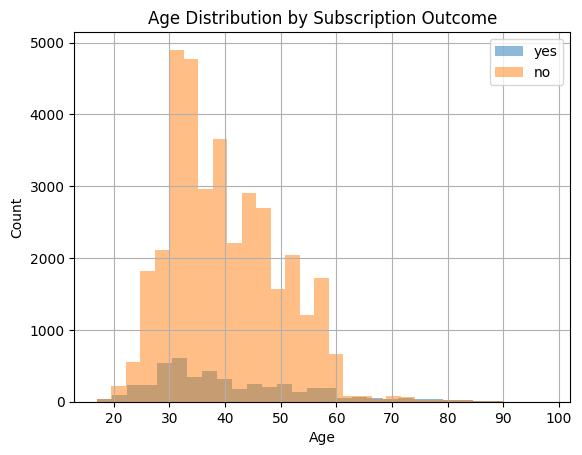

In [25]:
import matplotlib.pyplot as plt

df_clean[df_clean['y']=='yes']['age'].hist(bins=30, alpha=0.5, label='yes')
df_clean[df_clean['y']=='no']['age'].hist(bins=30, alpha=0.5, label='no', density=False)
plt.legend()
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Subscription Outcome')
plt.show()

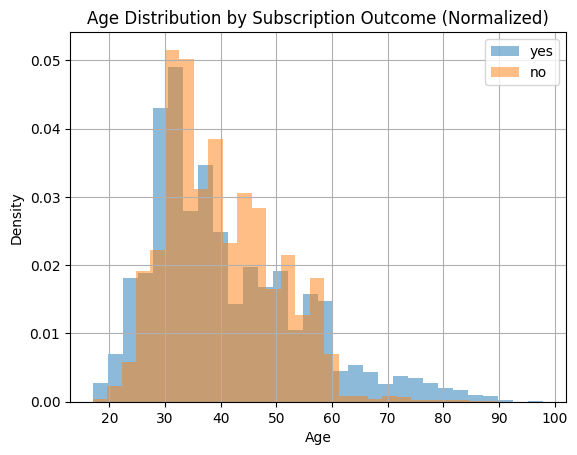

In [26]:
df_clean[df_clean['y']=='yes']['age'].hist(bins=30, alpha=0.5, label='yes', density=True)
df_clean[df_clean['y']=='no']['age'].hist(bins=30, alpha=0.5, label='no', density=True)
plt.legend()
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age Distribution by Subscription Outcome (Normalized)')
plt.show()

In [3]:
import joblib
import os

# Create 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

joblib.dump(rf_model, 'data/model.pkl')

NameError: name 'rf_model' is not defined

In [28]:
!ls -la model.pkl

-rw-r--r-- 1 root root 189256953 Sep 13 07:17 model.pkl


In [4]:
joblib.dump(X_train.columns.tolist(), 'data/model_columns.pkl')

NameError: name 'X_train' is not defined

In [31]:
!pip install streamlit
import streamlit as st

page = st.sidebar.selectbox("Navigate", ["Business Problem", "Data Insights", "Prediction"])

if page == "Business Problem":
    st.title("Bank Term Deposit Subscription Predictor")
    # write your business problem, objective, dataset info here

elif page == "Data Insights":
    st.title("Data Insights")
    # show charts + key stats here

elif page == "Prediction":
    st.title("Make a Prediction")
    # input fields + predict button here

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 58.0 MB/s eta 0:00:00


2026-09-13 07:24:56.866 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-13 07:24:56.868 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-13 07:24:56.868 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-13 07:24:56.871 WARNING streamlit.runtime.state.session_state_proxy: Session state does not function when running a script without `streamlit run`
2026-09-13 07:24:56.872 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-13 07:24:57.036 
  command:

    streamlit run /usr/local/lib/python3.13/

In [32]:
if page == "Business Problem":
    st.title("Bank Term Deposit Subscription Predictor")
    st.subheader("Business Problem")
    st.write("A bank runs phone-call marketing campaigns to sell term deposits, but calling every customer is costly, and most calls don't convert (~89% say no).")
    st.subheader("Analytics Objective")
    st.write("Develop a classification model that predicts whether a customer is likely to subscribe to a term deposit.")
    st.subheader("Dataset")
    st.write("UCI Bank Marketing dataset — 41,188 rows, 21 original columns, from a Portuguese bank's direct marketing campaigns.")
    st.subheader("Target Variable")
    st.write("y — Yes/No, whether the customer subscribed to a term deposit.")

2026-09-13 07:28:28.830 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-13 07:28:28.832 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-13 07:28:28.835 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-13 07:28:28.839 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-13 07:28:28.841 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-13 07:28:28.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-13 07:28:28.844 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-13 07:28:28.846 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

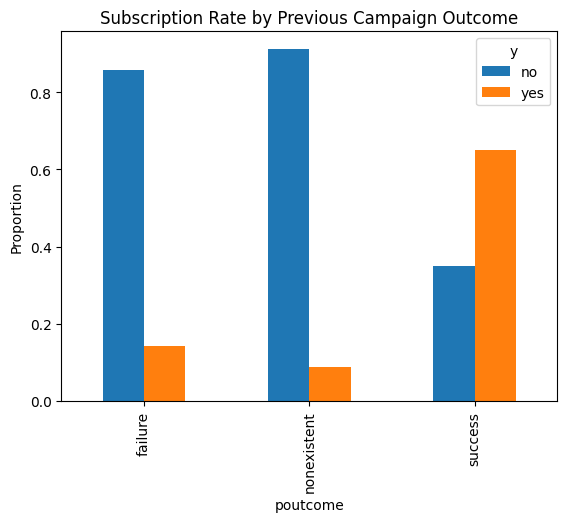

In [33]:
import pandas as pd
pd.crosstab(df_clean['poutcome'], df_clean['y'], normalize='index').plot(kind='bar')
plt.ylabel('Proportion')
plt.title('Subscription Rate by Previous Campaign Outcome')
plt.show()

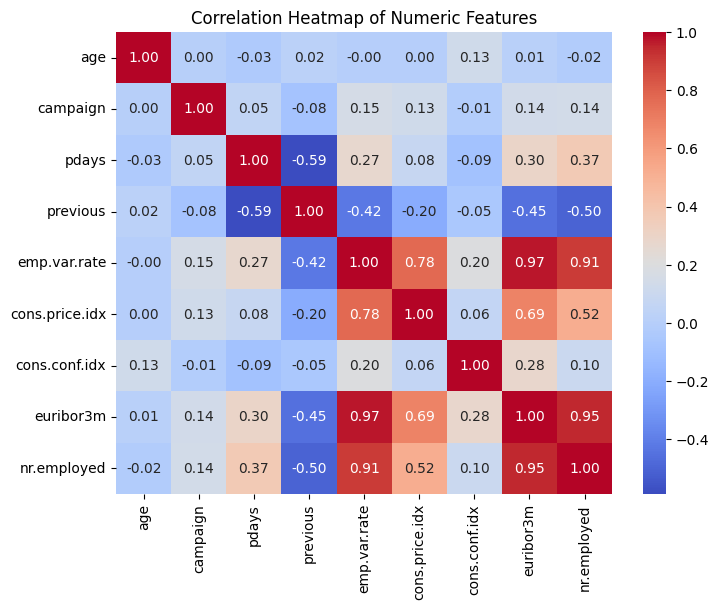

In [34]:
import seaborn as sns

numeric_cols = ['age','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
plt.figure(figsize=(8,6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [8]:
if page == "Data Insights":
    st.title("Data Insights")

    st.subheader("Age Distribution by Subscription Outcome")
    fig1, ax1 = plt.subplots()
    df_clean[df_clean['y']=='yes']['age'].hist(bins=30, alpha=0.5, label='yes', density=True, ax=ax1)
    df_clean[df_clean['y']=='no']['age'].hist(bins=30, alpha=0.5, label='no', density=True, ax=ax1)
    ax1.set_xlabel('Age')
    ax1.set_ylabel('Density')
    ax1.legend()
    st.pyplot(fig1)
    st.write("Young and retirement-age customers subscribe proportionally more than middle-aged customers, likely due to fewer financial obligations (e.g. no mortgage, no dependents).")

    st.subheader("Subscription Rate by Previous Campaign Outcome")
    fig2, ax2 = plt.subplots()
    pd.crosstab(df_clean['poutcome'], df_clean['y'], normalize='index').plot(kind='bar', ax=ax2)
    st.pyplot(fig2)
    st.write("Customers who previously subscribed successfully convert again at ~65%, compared to ~9-14% for others. The bank should prioritize recontacting past successful customers.")

    st.subheader("Correlation Heatmap of Economic Indicators")
    fig3, ax3 = plt.subplots(figsize=(8,6))
    sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax3)
    st.pyplot(fig3)
    st.write("Several economic indicators (emp.var.rate, euribor3m, nr.employed) are highly correlated with each other, indicating redundancy — one is often enough to capture the underlying trend.")
elif page == "Prediction":
    st.title("Make a Prediction")

    st.subheader("Enter Customer Details:")

    # Get unique values for categorical features from df_clean for dropdowns
    job_options = df_clean['job'].unique().tolist()
    marital_options = df_clean['marital'].unique().tolist()
    education_options = df_clean['education'].unique().tolist()
    housing_options = df_clean['housing'].unique().tolist()
    loan_options = df_clean['loan'].unique().tolist()
    contact_options = df_clean['contact'].unique().tolist()
    month_options = df_clean['month'].unique().tolist()
    day_of_week_options = df_clean['day_of_week'].unique().tolist()
    poutcome_options = df_clean['poutcome'].unique().tolist()

    # Input widgets
    age = st.slider("Age", int(df_clean['age'].min()), int(df_clean['age'].max()), int(df_clean['age'].mean()))
    job = st.selectbox("Job", job_options, index=job_options.index(df_clean['job'].mode()[0])) # default to mode
    marital = st.selectbox("Marital Status", marital_options, index=marital_options.index(df_clean['marital'].mode()[0]))
    education = st.selectbox("Education", education_options, index=education_options.index(df_clean['education'].mode()[0]))
    housing = st.radio("Housing Loan", housing_options, index=housing_options.index(df_clean['housing'].mode()[0]))
    loan = st.radio("Personal Loan", loan_options, index=loan_options.index(df_clean['loan'].mode()[0]))
    contact = st.selectbox("Contact Communication Type", contact_options, index=contact_options.index(df_clean['contact'].mode()[0]))
    month = st.selectbox("Last Contact Month of Year", month_options, index=month_options.index(df_clean['month'].mode()[0]))
    day_of_week = st.selectbox("Last Contact Day of Week", day_of_week_options, index=day_of_week_options.index(df_clean['day_of_week'].mode()[0]))

    campaign = st.number_input("Number of contacts performed during this campaign", min_value=1, value=int(df_clean['campaign'].mean()))
    pdays = st.number_input("Number of days since last contact from a previous campaign (999 means not previously contacted)", min_value=0, value=int(df_clean['pdays'].mean()))
    previous = st.number_input("Number of contacts performed before this campaign", min_value=0, value=int(df_clean['previous'].mean()))
    poutcome = st.selectbox("Outcome of the previous marketing campaign", poutcome_options, index=poutcome_options.index(df_clean['poutcome'].mode()[0]))

    emp_var_rate = st.number_input("Employment Variation Rate", value=float(df_clean['emp.var.rate'].mean()))
    cons_price_idx = st.number_input("Consumer Price Index", value=float(df_clean['cons.price.idx'].mean()))
    cons_conf_idx = st.number_input("Consumer Confidence Index", value=float(df_clean['cons.conf.idx'].mean()))
    euribor3m = st.number_input("Euribor 3 month rate", value=float(df_clean['euribor3m'].mean()))
    nr_employed = st.number_input("Number of Employees", value=float(df_clean['nr.employed'].mean()))


    if st.button("Predict Subscription"):
        # Create a dictionary to hold all feature values for a single prediction
        input_data_dict = {}

        # Numerical features
        input_data_dict['age'] = age
        input_data_dict['campaign'] = campaign
        input_data_dict['pdays'] = pdays
        input_data_dict['previous'] = previous
        input_data_dict['emp.var.rate'] = emp_var_rate
        input_data_dict['cons.price.idx'] = cons_price_idx
        input_data_dict['cons.conf.idx'] = cons_conf_idx
        input_data_dict['euribor3m'] = euribor3m
        input_data_dict['nr.employed'] = nr_employed

        # Derived boolean feature
        input_data_dict['was_previously_contacted'] = (pdays != 999)

        # Categorical features - one-hot encode
        categorical_features_for_dummies = ['job','marital','education','housing','loan','contact','month','day_of_week','poutcome']

        # Populate dummy variables with 0 initially for all possible one-hot encoded columns from model_columns
        for col in model_columns:
            # Check if it's a dummy variable column (contains an underscore after a categorical feature name)
            if any(col.startswith(f'{cat_feat}_') for cat_feat in categorical_features_for_dummies):
                input_data_dict[col] = 0

        # Set 1 for the selected categorical values
        # Check if the column exists in model_columns before setting to 1 (due to drop_first=True)
        if f'job_{job}' in model_columns: input_data_dict[f'job_{job}'] = 1
        if f'marital_{marital}' in model_columns: input_data_dict[f'marital_{marital}'] = 1
        if f'education_{education}' in model_columns: input_data_dict[f'education_{education}'] = 1
        if f'housing_{housing}' in model_columns: input_data_dict[f'housing_{housing}'] = 1
        if f'loan_{loan}' in model_columns: input_data_dict[f'loan_{loan}'] = 1
        if f'contact_{contact}' in model_columns: input_data_dict[f'contact_{contact}'] = 1
        if f'month_{month}' in model_columns: input_data_dict[f'month_{month}'] = 1
        if f'day_of_week_{day_of_week}' in model_columns: input_data_dict[f'day_of_week_{day_of_week}'] = 1
        if f'poutcome_{poutcome}' in model_columns: input_data_dict[f'poutcome_{poutcome}'] = 1

        # Create a DataFrame with the prediction data, ensuring all model_columns are present and in order
        prediction_df = pd.DataFrame(columns=model_columns)
        prediction_df.loc[0] = [input_data_dict.get(col, 0) for col in model_columns] # Use .get() for safety, default to 0 if key not found

        # Ensure boolean column is correct type if it was in model_columns (was_previously_contacted is boolean)
        if 'was_previously_contacted' in model_columns:
            prediction_df['was_previously_contacted'] = prediction_df['was_previously_contacted'].astype(bool)

        # Predict
        prediction = model.predict(prediction_df)
        prediction_proba = model.predict_proba(prediction_df)[:, 1] # Probability of 'yes'

        if prediction[0] == 1:
            st.success(f"Prediction: This customer is likely to subscribe! (Probability: {prediction_proba[0]:.2f})")
        else:
            st.info(f"Prediction: This customer is unlikely to subscribe. (Probability: {prediction_proba[0]:.2f})")

NameError: name 'page' is not defined

In [7]:
!pip install streamlit
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

model = joblib.load("data/model.pkl")
model_columns = joblib.load("data/model_columns.pkl")

df_clean = pd.read_csv("data/dataset.csv")  # your cleaned dataset, saved as CSV

numeric_cols = ['age','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

FileNotFoundError: [Errno 2] No such file or directory: 'data/model.pkl'

In [14]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

model = joblib.load("model.pkl")
model_columns = joblib.load("model_columns.pkl")
df_clean = pd.read_csv("data/dataset.csv")

numeric_cols = ['age','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

page = st.sidebar.selectbox("Navigate", ["Business Problem", "Data Insights", "Prediction"])

if page == "Business Problem":
    st.title("Bank Term Deposit Subscription Predictor")
    st.subheader("Business Problem")
    st.write("A bank runs phone-call marketing campaigns to sell term deposits, but calling every customer is costly, and most calls don't convert (~89% say no).")
    st.subheader("Analytics Objective")
    st.write("Develop a classification model that predicts whether a customer is likely to subscribe to a term deposit.")
    st.subheader("Dataset")
    st.write("UCI Bank Marketing dataset — 41,188 rows, 21 original columns, from a Portuguese bank's direct marketing campaigns.")
    st.subheader("Target Variable")
    st.write("y — Yes/No, whether the customer subscribed to a term deposit.")

elif page == "Data Insights":
    st.title("Data Insights")

    st.subheader("Age Distribution by Subscription Outcome")
    fig1, ax1 = plt.subplots()
    df_clean[df_clean['y']=='yes']['age'].hist(bins=30, alpha=0.5, label='yes', density=True, ax=ax1)
    df_clean[df_clean['y']=='no']['age'].hist(bins=30, alpha=0.5, label='no', density=True, ax=ax1)
    ax1.set_xlabel('Age')
    ax1.set_ylabel('Density')
    ax1.legend()
    st.pyplot(fig1)
    st.write("Young and retirement-age customers subscribe proportionally more than middle-aged customers, likely due to fewer financial obligations.")

    st.subheader("Subscription Rate by Previous Campaign Outcome")
    fig2, ax2 = plt.subplots()
    pd.crosstab(df_clean['poutcome'], df_clean['y'], normalize='index').plot(kind='bar', ax=ax2)
    st.pyplot(fig2)
    st.write("Customers who previously

Writing app.py


In [15]:
elif page == "Prediction":
    st.title("Make a Prediction")

    age = st.slider("Age", 17, 98, 40)
    job = st.selectbox("Job", df_clean['job'].unique())
    marital = st.selectbox("Marital Status", df_clean['marital'].unique())
    education = st.selectbox("Education", df_clean['education'].unique())
    campaign = st.slider("Number of contacts this campaign", 1, 56, 2)
    poutcome = st.selectbox("Previous Campaign Outcome", df_clean['poutcome'].unique())

    if st.button("Predict"):
        input_dict = {col: 0 for col in model_columns}
        input_dict['age'] = age
        input_dict['campaign'] = campaign
        # set one-hot columns to 1 based on selections
        for col, val in [('job', job), ('marital', marital), ('education', education), ('poutcome', poutcome)]:
            dummy_col = f"{col}_{val}"
            if dummy_col in input_dict:
                input_dict[dummy_col] = 1

        input_df = pd.DataFrame([input_dict])[model_columns]
        prediction = model.predict(input_df)[0]
        probability = model.predict_proba(input_df)[0][1]

        if prediction == 1:
            st.success(f"Prediction: Likely to Subscribe (probability: {probability:.2%})")
            st.write("Recommendation: Prioritize this customer for a call.")
        else:
            st.warning(f"Prediction: Unlikely to Subscribe (probability: {probability:.2%})")
            st.write("Recommendation: Lower priority for calling.")

SyntaxError: invalid syntax (1462707846.py, line 1)

In [16]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

model = joblib.load("model.pkl")
model_columns = joblib.load("model_columns.pkl")
df_clean = pd.read_csv("data/dataset.csv")

numeric_cols = ['age','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

page = st.sidebar.selectbox("Navigate", ["Business Problem", "Data Insights", "Prediction"])

if page == "Business Problem":
    st.title("Bank Term Deposit Subscription Predictor")
    st.subheader("Business Problem")
    st.write("A bank runs phone-call marketing campaigns to sell term deposits, but calling every customer is costly, and most calls don't convert (~89% say no).")
    st.subheader("Analytics Objective")
    st.write("Develop a classification model that predicts whether a customer is likely to subscribe to a term deposit.")
    st.subheader("Dataset")
    st.write("UCI Bank Marketing dataset — 41,188 rows, 21 original columns, from a Portuguese bank's direct marketing campaigns.")
    st.subheader("Target Variable")
    st.write("y — Yes/No, whether the customer subscribed to a term deposit.")

elif page == "Data Insights":
    st.title("Data Insights")

    st.subheader("Age Distribution by Subscription Outcome")
    fig1, ax1 = plt.subplots()
    df_clean[df_clean['y']=='yes']['age'].hist(bins=30, alpha=0.5, label='yes', density=True, ax=ax1)
    df_clean[df_clean['y']=='no']['age'].hist(bins=30, alpha=0.5, label='no', density=True, ax=ax1)
    ax1.set_xlabel('Age')
    ax1.set_ylabel('Density')
    ax1.legend()
    st.pyplot(fig1)
    st.write("Young and retirement-age customers subscribe proportionally more than middle-aged customers, likely due to fewer financial obligations.")

    st.subheader("Subscription Rate by Previous Campaign Outcome")
    fig2, ax2 = plt.subplots()
    pd.crosstab(df_clean['poutcome'], df_clean['y'], normalize='index').plot(kind='bar', ax=ax2)
    st.pyplot(fig2)
    st.write("Customers who previously subscribed successfully convert again at ~65%, compared to ~9-14% for others.")

    st.subheader("Correlation Heatmap of Economic Indicators")
    fig3, ax3 = plt.subplots(figsize=(8,6))
    sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax3)
    st.pyplot(fig3)
    st.write("Several economic indicators are highly correlated, indicating redundancy.")

elif page == "Prediction":
    st.title("Make a Prediction")

    age = st.slider("Age", 17, 98, 40)
    job = st.selectbox("Job", df_clean['job'].unique())
    marital = st.selectbox("Marital Status", df_clean['marital'].unique())
    education = st.selectbox("Education", df_clean['education'].unique())
    campaign = st.slider("Number of contacts this campaign", 1, 56, 2)
    poutcome = st.selectbox("Previous Campaign Outcome", df_clean['poutcome'].unique())

    if st.button("Predict"):
        input_dict = {col: 0 for col in model_columns}
        input_dict['age'] = age
        input_dict['campaign'] = campaign
        for col, val in [('job', job), ('marital', marital), ('education', education), ('poutcome', poutcome)]:
            dummy_col = f"{col}_{val}"
            if dummy_col in input_dict:
                input_dict[dummy_col] = 1

        input_df = pd.DataFrame([input_dict])[model_columns]
        prediction = model.predict(input_df)[0]
        probability = model.predict_proba(input_df)[0][1]

        if prediction == 1:
            st.success(f"Prediction: Likely to Subscribe (probability: {probability:.2%})")
            st.write("Recommendation: Prioritize this customer for a call.")
        else:
            st.warning(f"Prediction: Unlikely to Subscribe (probability: {probability:.2%})")
            st.write("Recommendation: Lower priority for calling.")

Overwriting app.py


In [17]:
%%writefile app.py

Overwriting app.py


In [18]:
import os
os.makedirs('data', exist_ok=True)
df_clean.to_csv('data/dataset.csv', index=False)

NameError: name 'df_clean' is not defined

In [19]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

model = joblib.load("model.pkl")
model_columns = joblib.load("model_columns.pkl")
df_clean = pd.read_csv("data/dataset.csv")

numeric_cols = ['age','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

page = st.sidebar.selectbox("Navigate", ["Business Problem", "Data Insights", "Prediction"])

if page == "Business Problem":
    st.title("Bank Term Deposit Subscription Predictor")
    st.subheader("Business Problem")
    st.write("A bank runs phone-call marketing campaigns to sell term deposits, but calling every customer is costly, and most calls don't convert (~89% say no).")
    st.subheader("Analytics Objective")
    st.write("Develop a classification model that predicts whether a customer is likely to subscribe to a term deposit.")
    st.subheader("Dataset")
    st.write("UCI Bank Marketing dataset - 41,188 rows, 21 original columns, from a Portuguese bank's direct marketing campaigns.")
    st.subheader("Target Variable")
    st.write("y - Yes/No, whether the customer subscribed to a term deposit.")

elif page == "Data Insights":
    st.title("Data Insights")

    st.subheader("Age Distribution by Subscription Outcome")
    fig1, ax1 = plt.subplots()
    df_clean[df_clean['y']=='yes']['age'].hist(bins=30, alpha=0.5, label='yes', density=True, ax=ax1)
    df_clean[df_clean['y']=='no']['age'].hist(bins=30, alpha=0.5, label='no', density=True, ax=ax1)
    ax1.set_xlabel('Age')
    ax1.set_ylabel('Density')
    ax1.legend()
    st.pyplot(fig1)
    st.write("Young and retirement-age customers subscribe proportionally more than middle-aged customers, likely due to fewer financial obligations.")

    st.subheader("Subscription Rate by Previous Campaign Outcome")
    fig2, ax2 = plt.subplots()
    pd.crosstab(df_clean['poutcome'], df_clean['y'], normalize='index').plot(kind='bar', ax=ax2)
    st.pyplot(fig2)
    st.write("Customers who previously subscribed successfully convert again at ~65%, compared to ~9-14% for others.")

    st.subheader("Correlation Heatmap of Economic Indicators")
    fig3, ax3 = plt.subplots(figsize=(8,6))
    sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax3)
    st.pyplot(fig3)
    st.write("Several economic indicators are highly correlated, indicating redundancy.")

elif page == "Prediction":
    st.title("Make a Prediction")

    age = st.slider("Age", 17, 98, 40)
    job = st.selectbox("Job", df_clean['job'].unique())
    marital = st.selectbox("Marital Status", df_clean['marital'].unique())
    education = st.selectbox("Education", df_clean['education'].unique())
    campaign = st.slider("Number of contacts this campaign", 1, 56, 2)
    poutcome = st.selectbox("Previous Campaign Outcome", df_clean['poutcome'].unique())

    if st.button("Predict"):
        input_dict = {col: 0 for col in model_columns}
        input_dict['age'] = age
        input_dict['campaign'] = campaign
        for col, val in [('job', job), ('marital', marital), ('education', education), ('poutcome', poutcome)]:
            dummy_col = f"{col}_{val}"
            if dummy_col in input_dict:
                input_dict[dummy_col] = 1

        input_df = pd.DataFrame([input_dict])[model_columns]
        prediction = model.predict(input_df)[0]
        probability = model.predict_proba(input_df)[0][1]

        if prediction == 1:
            st.success(f"Prediction: Likely to Subscribe (probability: {probability:.2%})")
            st.write("Recommendation: Prioritize this customer for a call.")
        else:
            st.warning(f"Prediction: Unlikely to Subscribe (probability: {probability:.2%})")
            st.write("Recommendation: Lower priority for calling.")

Overwriting app.py


In [20]:
import os
os.makedirs('data', exist_ok=True)
df_clean.to_csv('data/dataset.csv', index=False)

NameError: name 'df_clean' is not defined

In [21]:
%whos

Variable   Type      Data/Info
------------------------------
joblib     module    <module 'joblib' from '/u<...>ages/joblib/__init__.py'>
os         module    <module 'os' (frozen)>
pd         module    <module 'pandas' from '/u<...>ages/pandas/__init__.py'>
plt        module    <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns        module    <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
st         module    <module 'streamlit' from <...>s/streamlit/__init__.py'>


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib

# Reload original data
url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
!wget -q {url} -O bank_marketing.zip
!unzip -o -q bank_marketing.zip
!unzip -o -q bank-additional.zip
df = pd.read_csv("bank-additional/bank-additional-full.csv", sep=';')

# Cleaning
df_clean = df.drop(columns=['duration', 'default'])
df_clean['was_previously_contacted'] = df_clean['pdays'] != 999

# Encoding
df_model = pd.get_dummies(df_clean, columns=['job','marital','education','housing','loan','contact','month','day_of_week','poutcome'], drop_first=True)
df_model['y'] = df_model['y'].map({'no': 0, 'yes': 1})

X = df_model.drop(columns=['y'])
y = df_model['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train final model
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Save model + columns
joblib.dump(rf_model, 'model.pkl')
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

print("df_clean shape:", df_clean.shape)
print("Done - model retrained and saved.")

df_clean shape: (41188, 20)
Done - model retrained and saved.


In [24]:
import os
os.makedirs('data', exist_ok=True)
df_clean.to_csv('data/dataset.csv', index=False)

In [25]:
!pip install streamlit -q

In [ ]:
!npm install -g localtunnel -q
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 5s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.2
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.2
npm notice To update run: npm install -g npm@12.0.2
npm notice
⠼⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://sweet-mice-carry.loca.lt
